## Ex 10-Implementation of Random Forest Algorithm for Weather Prediction
## Name : Kishore S M
## Reg no : 212224230131

--- Feature Engineering Summary ---
Original rows: 1000
Processed rows (after lags/cleaning): 998
Final high-performance feature set: ['hum', 'pressure', 'wind_speed', 'illumination', 'co2', 'hour_sin', 'hour_cos', 'tem_lag1', 'pm2_5_lag1', 'tsr_lag1']


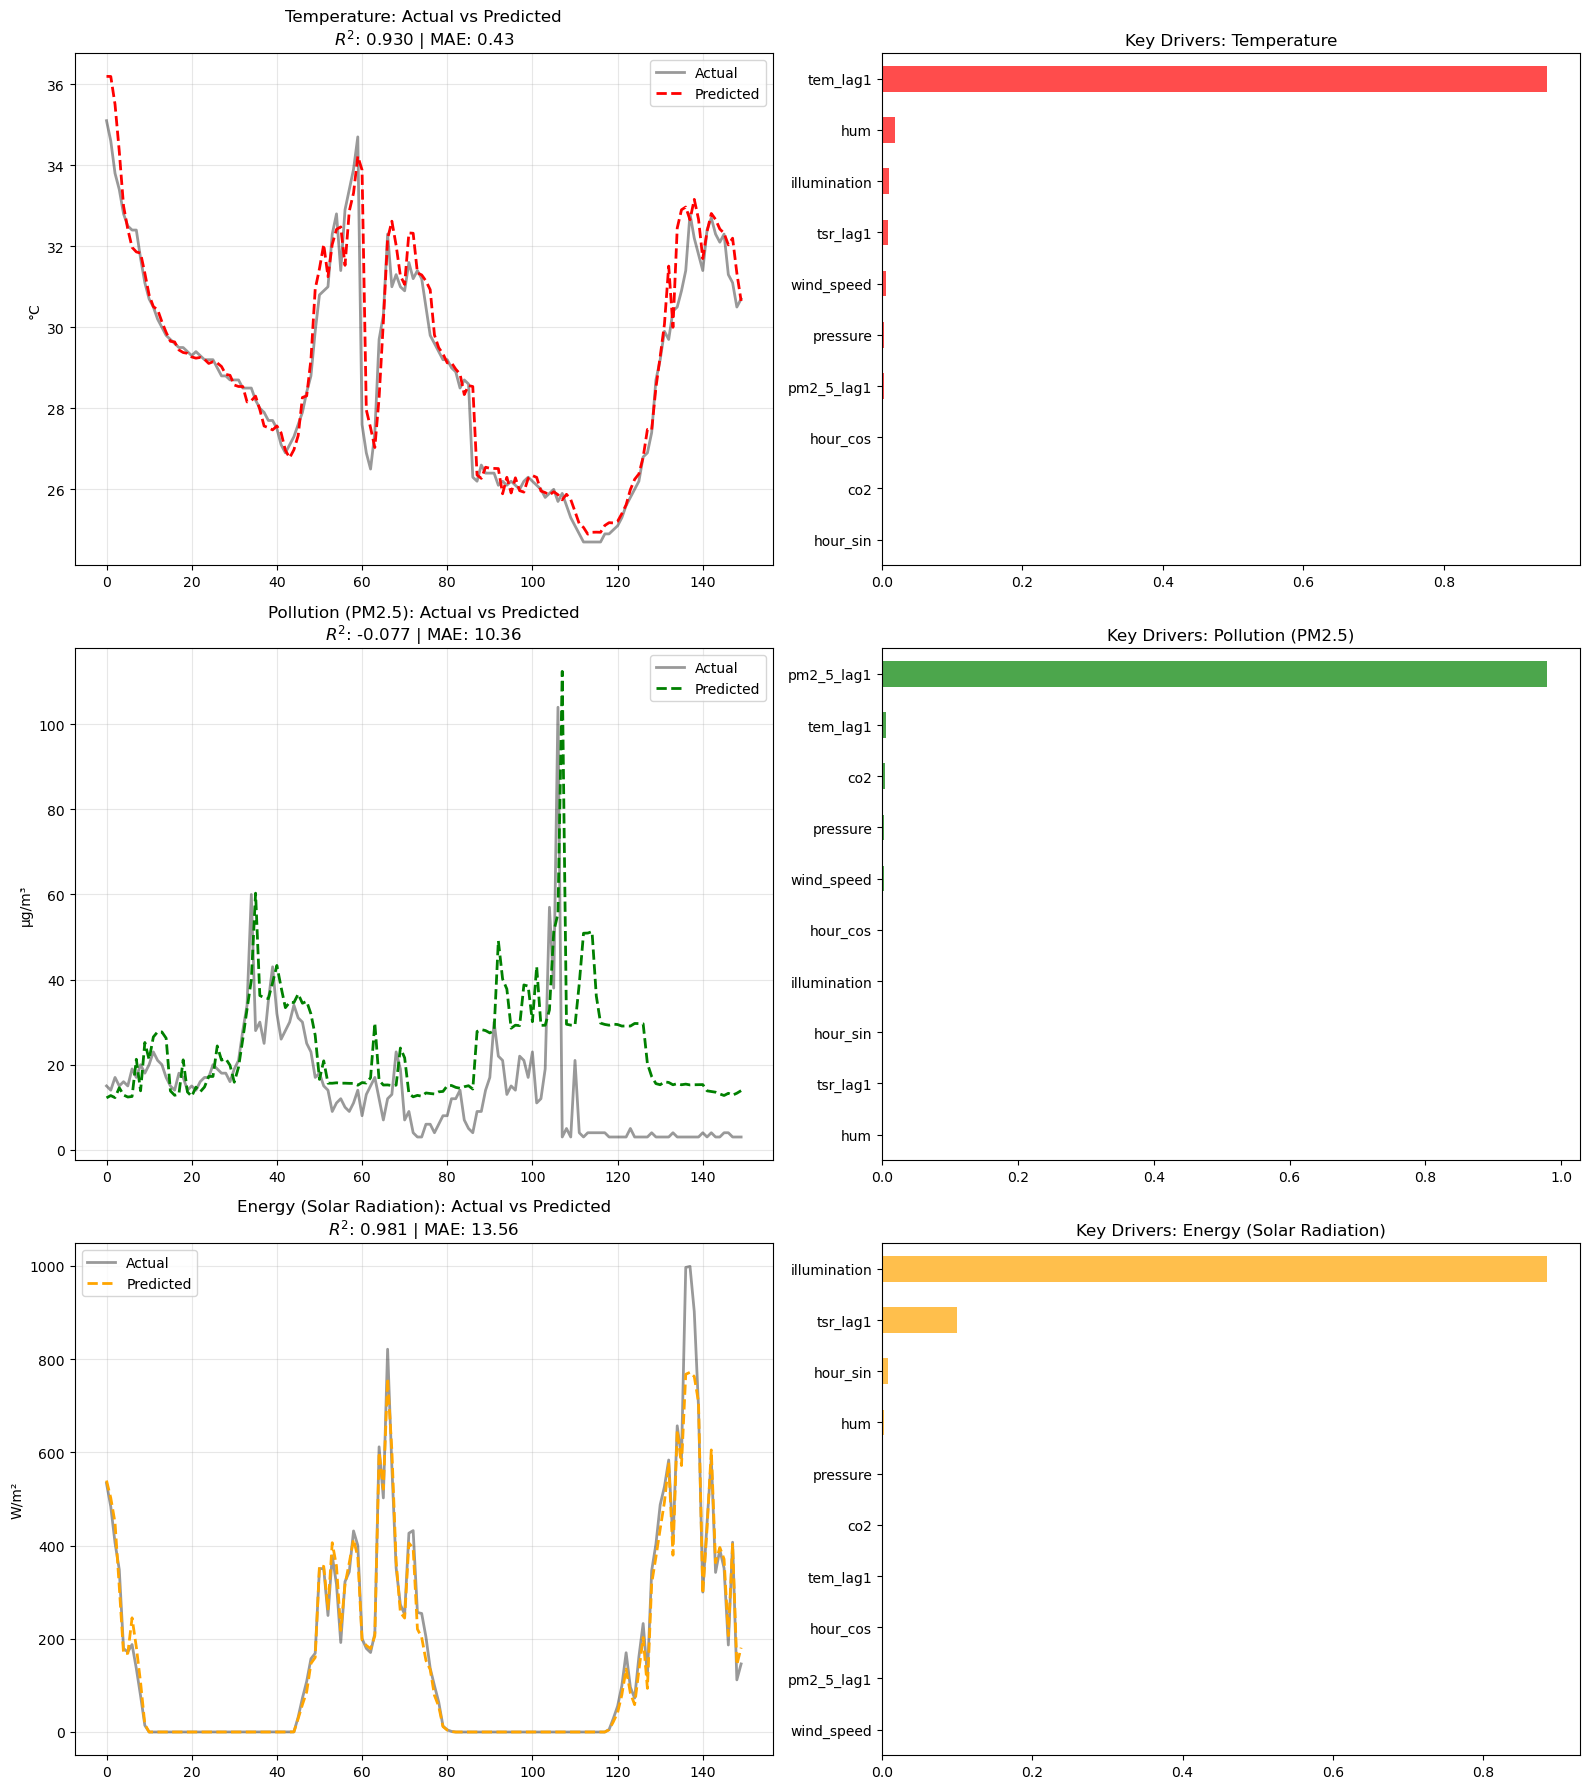


--- FINAL MODEL PERFORMANCE SUMMARY ---

🔹 Temperature
R² Score        : 0.9296
Accuracy (%)    : 92.96%
MAE             : 0.4265
RMSE            : 0.7699

🔹 Pollution (PM2.5)
R² Score        : -0.0766
Accuracy (%)    : 0.00%
MAE             : 10.3643
RMSE            : 15.7277

🔹 Energy (Solar Radiation)
R² Score        : 0.9805
Accuracy (%)    : 98.05%
MAE             : 13.5585
RMSE            : 33.7748

--- NEXT STEP PREDICTIONS (Using Latest Data) ---
Predicted Temperature: 30.86 °C
Predicted Pollution (PM2.5): 13.88 µg/m³
Predicted Energy (Solar Radiation): 185.28 W/m²


In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


df = pd.read_csv("weather-station-eee-block_2024_07_13.csv")
df.columns = df.columns.str.strip()

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

cols_to_fill = ['tem', 'pm2_5', 'tsr', 'hum', 'pressure', 'wind_speed', 'illumination', 'co2']
for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear', limit=10)

df['hour'] = df['time'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

targets = ['tem', 'pm2_5', 'tsr']
for t in targets:
    df[f'{t}_lag1'] = df[t].shift(1)
    df[f'{t}_lag2'] = df[t].shift(2)


processed_df = df.dropna(subset=['tem_lag2', 'pm2_5_lag2', 'tsr_lag2', 'hum', 'pressure']).reset_index(drop=True)
processed_df.to_csv("combined_processed_weather_data.csv", index=False)

features = [
    'hum', 'pressure', 'wind_speed', 'illumination', 'co2',
    'hour_sin', 'hour_cos', 'tem_lag1', 'pm2_5_lag1', 'tsr_lag1'
]

print("--- Feature Engineering Summary ---")
print(f"Original rows: {len(df)}")
print(f"Processed rows (after lags/cleaning): {len(processed_df)}")
print(f"Final high-performance feature set:",features)

split_idx = int(len(processed_df) * 0.8)
train, test = processed_df.iloc[:split_idx], processed_df.iloc[split_idx:]
X_train, X_test = train[features], test[features]

models = {}
results = {}

target_meta = {
    'tem': ('Temperature', '°C', 'red'),
    'pm2_5': ('Pollution (PM2.5)', 'µg/m³', 'green'),
    'tsr': ('Energy (Solar Radiation)', 'W/m²', 'orange')
}

for target in targets:
    y_train, y_test = train[target], test[target]
    
   
    model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    models[target] = model
    
    results[target] = {
        'r2': r2_score(y_test, preds),
        'mae': mean_absolute_error(y_test, preds),
        'preds': preds,
        'actual': y_test.values
    }


fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for i, target in enumerate(targets):
    label, unit, color = target_meta[target]
    res = results[target]
    
  
    axes[i, 0].plot(res['actual'][-150:], label='Actual', color='black', alpha=0.4, linewidth=2)
    axes[i, 0].plot(res['preds'][-150:], label='Predicted', color=color, linestyle='--', linewidth=2)
    axes[i, 0].set_title(f"{label}: Actual vs Predicted\n$R^2$: {res['r2']:.3f} | MAE: {res['mae']:.2f}")
    axes[i, 0].set_ylabel(unit)
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    importances = pd.Series(models[target].feature_importances_, index=features).sort_values()
    importances.plot(kind='barh', ax=axes[i, 1], color=color, alpha=0.7)
    axes[i, 1].set_title(f"Key Drivers: {label}")

plt.tight_layout()
plt.show()

last_row = processed_df.iloc[-1]
latest_data = pd.DataFrame([{
    'hum': last_row['hum'], 'pressure': last_row['pressure'], 'wind_speed': last_row['wind_speed'],
    'illumination': last_row['illumination'], 'co2': last_row['co2'],
    'hour_sin': last_row['hour_sin'], 'hour_cos': last_row['hour_cos'],
    'tem_lag1': last_row['tem'], 'pm2_5_lag1': last_row['pm2_5'], 'tsr_lag1': last_row['tsr']
}])
print("\n--- FINAL MODEL PERFORMANCE SUMMARY ---")

for target in targets:
    res = results[target]
    
    r2 = res['r2']
    mae = res['mae']
    rmse = np.sqrt(mean_squared_error(res['actual'], res['preds']))
    
    # Convert R² to percentage accuracy
    accuracy = max(0, r2) * 100
    
    print(f"\n🔹 {target_meta[target][0]}")
    print(f"R² Score        : {r2:.4f}")
    print(f"Accuracy (%)    : {accuracy:.2f}%")
    print(f"MAE             : {mae:.4f}")
    print(f"RMSE            : {rmse:.4f}")

print("\n--- NEXT STEP PREDICTIONS (Using Latest Data) ---")
for target in targets:
    pred_val = models[target].predict(latest_data)[0]
    print(f"Predicted {target_meta[target][0]}: {pred_val:.2f} {target_meta[target][1]}")
